<a href="https://colab.research.google.com/github/ajit-ai/Data_Science/blob/main/Generative_Adversarial_Network_(GAN).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

This code defines a simple Energy-Based Model (EBM) in PyTorch. It consists of two linear layers with a ReLU activation in between. The forward method calculates the energy of the input data. The code then creates an instance of the EBM, generates random data, calculates the energy, computes a loss (mean energy), and performs a backward pass to compute gradients. Finally, it prints the weights and biases of the first linear layer.

In [1]:
import torch
import torch.nn as nn

class EBM(nn.Module):
    def __init__(self):
        super().__init__()
        self.energy = nn.Sequential(
            nn.Linear(784, 128),
            nn.ReLU(),
            nn.Linear(128, 1)
        )

    def forward(self, x):
        return self.energy(x)

model = EBM()
data = torch.randn(32, 784)
energy = model(data)
loss = torch.mean(energy)
loss.backward()
#print the EBM
print(model.energy[0].weight)
print(model.energy[0].bias)


Parameter containing:
tensor([[ 0.0288, -0.0091, -0.0298,  ...,  0.0280,  0.0306, -0.0318],
        [ 0.0289, -0.0103,  0.0012,  ..., -0.0216,  0.0092,  0.0335],
        [-0.0147,  0.0269, -0.0119,  ..., -0.0077,  0.0087,  0.0252],
        ...,
        [ 0.0011, -0.0058, -0.0131,  ...,  0.0347,  0.0173, -0.0058],
        [-0.0283,  0.0262,  0.0047,  ..., -0.0097,  0.0056,  0.0067],
        [-0.0274, -0.0058,  0.0042,  ..., -0.0020,  0.0023, -0.0041]],
       requires_grad=True)
Parameter containing:
tensor([-0.0340,  0.0185,  0.0116,  0.0113, -0.0152, -0.0076, -0.0068,  0.0048,
        -0.0132,  0.0300,  0.0301,  0.0218, -0.0119,  0.0038,  0.0122,  0.0341,
         0.0331, -0.0061,  0.0294,  0.0274,  0.0160,  0.0301,  0.0180,  0.0034,
         0.0126, -0.0202, -0.0148,  0.0250,  0.0242, -0.0047,  0.0105,  0.0231,
         0.0068,  0.0145,  0.0081,  0.0323,  0.0114,  0.0175,  0.0198,  0.0351,
        -0.0218,  0.0106,  0.0278, -0.0155, -0.0045,  0.0233,  0.0058, -0.0136,
         0.0069

In [2]:
import pymc as pm
import numpy as np

with pm.Model() as model:
    mu = pm.Normal('mu', mu=0, sigma=1)
    obs = pm.Normal('obs', mu=mu, sigma=1, observed=np.random.randn(100))
    trace = pm.sample(1000)
print(pm.summary(trace))

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu]


c:\Users\Lenovo\AppData\Local\Programs\Python\Python312\Lib\site-packages\rich\live.py:256: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 32 seconds.


     mean   sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
mu  0.089  0.1  -0.098    0.282      0.002    0.001    1644.0    2700.0    1.0


In [3]:
import torch
import torch.nn as nn

class DBN(nn.Module):
    def __init__(self):
        super().__init__()
        self.rbm1 = nn.Linear(784, 128)
        self.rbm2 = nn.Linear(128, 64)

    def forward(self, x):
        x = torch.sigmoid(self.rbm1(x))
        return torch.sigmoid(self.rbm2(x))

model = DBN()
data = torch.randn(32, 784)
output = model(data)

#print the DBN
print(model.rbm1.weight)
print(model.rbm1.bias)
print(model.rbm2.weight)
print(model.rbm2.bias)


Parameter containing:
tensor([[ 0.0289,  0.0355, -0.0079,  ..., -0.0309, -0.0300,  0.0315],
        [-0.0286,  0.0345, -0.0109,  ...,  0.0043,  0.0148,  0.0297],
        [-0.0016, -0.0122,  0.0197,  ..., -0.0023,  0.0155, -0.0301],
        ...,
        [ 0.0167, -0.0332, -0.0020,  ..., -0.0048,  0.0282,  0.0127],
        [-0.0087, -0.0254, -0.0097,  ...,  0.0235, -0.0108,  0.0201],
        [-0.0166,  0.0063, -0.0285,  ...,  0.0305, -0.0161, -0.0169]],
       requires_grad=True)
Parameter containing:
tensor([-0.0293,  0.0294, -0.0061, -0.0054,  0.0079,  0.0316,  0.0013,  0.0318,
         0.0357, -0.0297, -0.0012,  0.0102,  0.0259,  0.0312, -0.0276, -0.0009,
         0.0222, -0.0127,  0.0066, -0.0093, -0.0204, -0.0305,  0.0320, -0.0224,
         0.0010, -0.0169,  0.0227, -0.0118, -0.0310, -0.0337, -0.0241, -0.0227,
        -0.0279,  0.0181, -0.0192,  0.0024,  0.0226,  0.0273,  0.0071,  0.0287,
        -0.0259,  0.0346,  0.0209,  0.0091, -0.0312, -0.0260,  0.0335, -0.0107,
         0.0011

Using data [Only 4 moments]


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_16264\218584145.py:71: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  return v.data.storage().tolist()


Epoch 0: D (0.9101581573486328 real_err, 0.5159025192260742 fake_err) G (0.9054069519042969 err); Real Dist ([np.float64(3.9759266419410704), np.float64(1.24502727722379)]),  Fake Dist ([np.float64(-0.245376400411129), np.float64(0.04844993832281739)]) 
Epoch 100: D (0.6074704527854919 real_err, 0.6084381937980652 fake_err) G (0.7417919635772705 err); Real Dist ([np.float64(3.994800125360489), np.float64(1.2717682775762071)]),  Fake Dist ([np.float64(2.038433675289154), np.float64(0.009509941883344353)]) 
Epoch 200: D (0.2620224356651306 real_err, 0.29920926690101624 fake_err) G (1.237186074256897 err); Real Dist ([np.float64(4.023235457777977), np.float64(1.2467178755611747)]),  Fake Dist ([np.float64(3.0547089939117433), np.float64(0.367511702235734)]) 
Epoch 300: D (0.4818218946456909 real_err, 0.4683368504047394 fake_err) G (0.8141818046569824 err); Real Dist ([np.float64(3.9757937882244585), np.float64(1.2252074650598814)]),  Fake Dist ([np.float64(5.597505252838134), np.float64(2

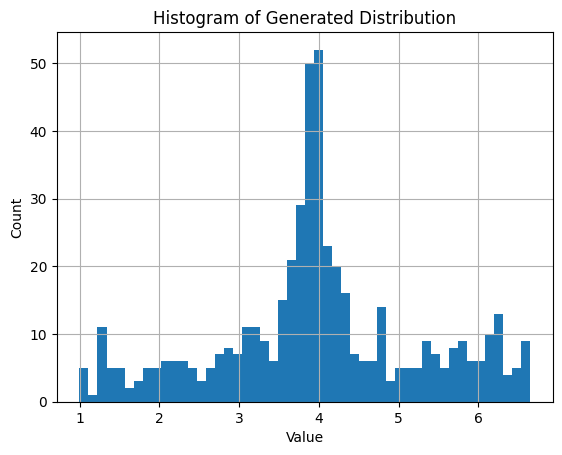

In [4]:
#!/usr/bin/env python

# Generative Adversarial Networks (GAN) example in PyTorch. Tested with PyTorch 0.4.1, Python 3.6.7 (Nov 2018)
# See related blog post at https://medium.com/@devnag/generative-adversarial-networks-gans-in-50-lines-of-code-pytorch-e81b79659e3f#.sch4xgsa9

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.autograd import Variable

matplotlib_is_available = True
try:
  from matplotlib import pyplot as plt
except ImportError:
  print("Will skip plotting; matplotlib is not available.")
  matplotlib_is_available = False

# Data params
data_mean = 4
data_stddev = 1.25

# ### Uncomment only one of these to define what data is actually sent to the Discriminator
#(name, preprocess, d_input_func) = ("Raw data", lambda data: data, lambda x: x)
#(name, preprocess, d_input_func) = ("Data and variances", lambda data: decorate_with_diffs(data, 2.0), lambda x: x * 2)
#(name, preprocess, d_input_func) = ("Data and diffs", lambda data: decorate_with_diffs(data, 1.0), lambda x: x * 2)
(name, preprocess, d_input_func) = ("Only 4 moments", lambda data: get_moments(data), lambda x: 4)

print("Using data [%s]" % (name))

# ##### DATA: Target data and generator input data

def get_distribution_sampler(mu, sigma):
    return lambda n: torch.Tensor(np.random.normal(mu, sigma, (1, n)))  # Gaussian

def get_generator_input_sampler():
    return lambda m, n: torch.rand(m, n)  # Uniform-dist data into generator, _NOT_ Gaussian

# ##### MODELS: Generator model and discriminator model

class Generator(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, f):
        super(Generator, self).__init__()
        self.map1 = nn.Linear(input_size, hidden_size)
        self.map2 = nn.Linear(hidden_size, hidden_size)
        self.map3 = nn.Linear(hidden_size, output_size)
        self.f = f

    def forward(self, x):
        x = self.map1(x)
        x = self.f(x)
        x = self.map2(x)
        x = self.f(x)
        x = self.map3(x)
        return x

class Discriminator(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, f):
        super(Discriminator, self).__init__()
        self.map1 = nn.Linear(input_size, hidden_size)
        self.map2 = nn.Linear(hidden_size, hidden_size)
        self.map3 = nn.Linear(hidden_size, output_size)
        self.f = f

    def forward(self, x):
        x = self.f(self.map1(x))
        x = self.f(self.map2(x))
        return self.f(self.map3(x))

def extract(v):
    return v.data.storage().tolist()

def stats(d):
    return [np.mean(d), np.std(d)]

def get_moments(d):
    # Return the first 4 moments of the data provided
    mean = torch.mean(d)
    diffs = d - mean
    var = torch.mean(torch.pow(diffs, 2.0))
    std = torch.pow(var, 0.5)
    zscores = diffs / std
    skews = torch.mean(torch.pow(zscores, 3.0))
    kurtoses = torch.mean(torch.pow(zscores, 4.0)) - 3.0  # excess kurtosis, should be 0 for Gaussian
    final = torch.cat((mean.reshape(1,), std.reshape(1,), skews.reshape(1,), kurtoses.reshape(1,)))
    return final

def decorate_with_diffs(data, exponent, remove_raw_data=False):
    mean = torch.mean(data.data, 1, keepdim=True)
    mean_broadcast = torch.mul(torch.ones(data.size()), mean.tolist()[0][0])
    diffs = torch.pow(data - Variable(mean_broadcast), exponent)
    if remove_raw_data:
        return torch.cat([diffs], 1)
    else:
        return torch.cat([data, diffs], 1)

def train():
    # Model parameters
    g_input_size = 1      # Random noise dimension coming into generator, per output vector
    g_hidden_size = 5     # Generator complexity
    g_output_size = 1     # Size of generated output vector
    d_input_size = 500    # Minibatch size - cardinality of distributions
    d_hidden_size = 10    # Discriminator complexity
    d_output_size = 1     # Single dimension for 'real' vs. 'fake' classification
    minibatch_size = d_input_size

    d_learning_rate = 1e-3
    g_learning_rate = 1e-3
    sgd_momentum = 0.9

    num_epochs = 5000
    print_interval = 100
    d_steps = 20
    g_steps = 20

    dfe, dre, ge = 0, 0, 0
    d_real_data, d_fake_data, g_fake_data = None, None, None

    discriminator_activation_function = torch.sigmoid
    generator_activation_function = torch.tanh

    d_sampler = get_distribution_sampler(data_mean, data_stddev)
    gi_sampler = get_generator_input_sampler()
    G = Generator(input_size=g_input_size,
                  hidden_size=g_hidden_size,
                  output_size=g_output_size,
                  f=generator_activation_function)
    D = Discriminator(input_size=d_input_func(d_input_size),
                      hidden_size=d_hidden_size,
                      output_size=d_output_size,
                      f=discriminator_activation_function)
    criterion = nn.BCELoss()  # Binary cross entropy: http://pytorch.org/docs/nn.html#bceloss
    d_optimizer = optim.SGD(D.parameters(), lr=d_learning_rate, momentum=sgd_momentum)
    g_optimizer = optim.SGD(G.parameters(), lr=g_learning_rate, momentum=sgd_momentum)

    for epoch in range(num_epochs):
        for d_index in range(d_steps):
            # 1. Train D on real+fake
            D.zero_grad()

            #  1A: Train D on real
            d_real_data = Variable(d_sampler(d_input_size))
            d_real_decision = D(preprocess(d_real_data))
            d_real_error = criterion(d_real_decision, Variable(torch.ones([1])))  # ones = true
            d_real_error.backward() # compute/store gradients, but don't change params

            #  1B: Train D on fake
            d_gen_input = Variable(gi_sampler(minibatch_size, g_input_size))
            d_fake_data = G(d_gen_input).detach()  # detach to avoid training G on these labels
            d_fake_decision = D(preprocess(d_fake_data.t()))
            d_fake_error = criterion(d_fake_decision, Variable(torch.zeros([1])))  # zeros = fake
            d_fake_error.backward()
            d_optimizer.step()     # Only optimizes D's parameters; changes based on stored gradients from backward()

            dre, dfe = extract(d_real_error)[0], extract(d_fake_error)[0]

        for g_index in range(g_steps):
            # 2. Train G on D's response (but DO NOT train D on these labels)
            G.zero_grad()

            gen_input = Variable(gi_sampler(minibatch_size, g_input_size))
            g_fake_data = G(gen_input)
            dg_fake_decision = D(preprocess(g_fake_data.t()))
            g_error = criterion(dg_fake_decision, Variable(torch.ones([1])))  # Train G to pretend it's genuine

            g_error.backward()
            g_optimizer.step()  # Only optimizes G's parameters
            ge = extract(g_error)[0]

        if epoch % print_interval == 0:
            print("Epoch %s: D (%s real_err, %s fake_err) G (%s err); Real Dist (%s),  Fake Dist (%s) " %
                  (epoch, dre, dfe, ge, stats(extract(d_real_data)), stats(extract(d_fake_data))))

    if matplotlib_is_available:
        print("Plotting the generated distribution...")
        values = extract(g_fake_data)
        print(" Values: %s" % (str(values)))
        plt.hist(values, bins=50)
        plt.xlabel('Value')
        plt.ylabel('Count')
        plt.title('Histogram of Generated Distribution')
        plt.grid(True)
        plt.show()


train()